#### 1) Setup & Data Loading

* Importe the Palmer's Penguins dataset from Kaggle

In [ ]:

# Import local : uniquement ce qui est utilisé ici
import seaborn as sns
import pandas as pd

# Dataset penguins depuis seaborn (équivalent au dataset Palmer Penguins)
penguins = sns.load_dataset("penguins")

# Aperçu
display(penguins.head())

# Q1 (1/2) — shape + types
print("Shape :", penguins.shape)
penguins.info()

# Détection colonnes numériques vs catégorielles
import numpy as np
numeric_cols = penguins.select_dtypes(include=np.number).columns.tolist()
cat_cols = penguins.select_dtypes(exclude=np.number).columns.tolist()
print("Numérical :", numeric_cols)
print("Catégorical :", cat_cols)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Shape : (344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
Numérical : ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Catégorical : ['species', 'island', 'sex']


**Q1** (check): How many rows and columns does the dataset have? Which columns are numeric vs categorical?

In [12]:
#Your code here
print("There is 344 rows and 7 columns in the dataset. The following columns are numerical:", numeric_cols, "and the following columns are categorical:", cat_cols)

There is 344 rows and 7 columns in the dataset. The following columns are numerical: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'] and the following columns are categorical: ['species', 'island', 'sex']


#### 2) Basic EDA (Exploratory Data Analysis)

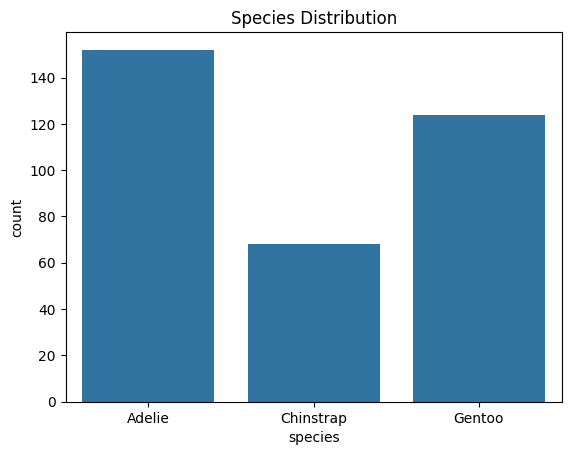

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=penguins, x="species")
plt.title("Species Distribution")
plt.show()

**Q2**: Which columns contain missing values? What strategy will you use to handle them?

In [15]:

import pandas as pd

na_counts = penguins.isna().sum().sort_values(ascending=False)
display(na_counts)

print("For this TD we will drop incomplete rows ( it's simple, we avoid leakage; trees don’t need scaling or imputation).")

sex                  11
bill_depth_mm         2
bill_length_mm        2
flipper_length_mm     2
body_mass_g           2
island                0
species               0
dtype: int64

For this TD we will drop incomplete rows ( it's simple, we avoid leakage; trees don’t need scaling or imputation).


**Q3**: Is the dataset balanced across the three species?

In [16]:

display(penguins["species"].value_counts())
display(penguins["species"].value_counts(normalize=True).round(2))

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

species
Adelie       0.44
Gentoo       0.36
Chinstrap    0.20
Name: proportion, dtype: float64

The dataset is not balanced as we see above we go from 152 Adelie to 124 Gentoo to 68 Chinstrap

#### 3) Data Cleaning & Encoding

* We’ll keep only rows with complete values for simplicity.

In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = penguins.dropna().copy()

le_species = LabelEncoder()
df["species"] = le_species.fit_transform(df["species"])

le_island = LabelEncoder()
le_sex = LabelEncoder()
df["island"] = le_island.fit_transform(df["island"])
df["sex"] = le_sex.fit_transform(df["sex"])

display(df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
4,0,2,36.7,19.3,193.0,3450.0,0
5,0,2,39.3,20.6,190.0,3650.0,1


**Q4**: Why don’t we need to scale features for Decision Trees?

In [18]:
print("We don’t need scaling for Decision Trees because they split using thresholds on ordered values (example :  feature equal or below threshold). Only the rank/order matters, not the magnitude")

We don’t need scaling for Decision Trees because they split using thresholds on ordered values (example :  feature equal or below threshold). Only the rank/order matters, not the magnitude


#### 4) Train/Test Split

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop(columns="species")
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keep class proportions
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train distribution:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  distribution:", y_test.value_counts(normalize=True).round(3).to_dict())

Train: (266, 6)  Test: (67, 6)
Train distribution: {0: 0.44, 2: 0.357, 1: 0.203}
Test  distribution: {0: 0.433, 2: 0.358, 1: 0.209}


**Q5**: Why do we use stratify=y in this split?

we do it because stratify=y preserves the label proportions in train and test it avoids accidental class imbalance

#### 5) Baseline Decision Tree

Baseline accuracy: 0.955


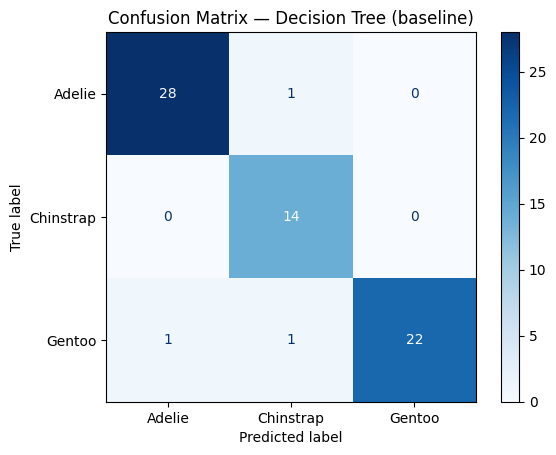

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_species.classes_)
disp.plot(values_format='d', cmap="Blues")
plt.title("Confusion Matrix — Decision Tree (baseline)")
plt.show()

**Q6**: Which classes are the most/least confounded? What might cause that?

#### 6) Visualize the Tree

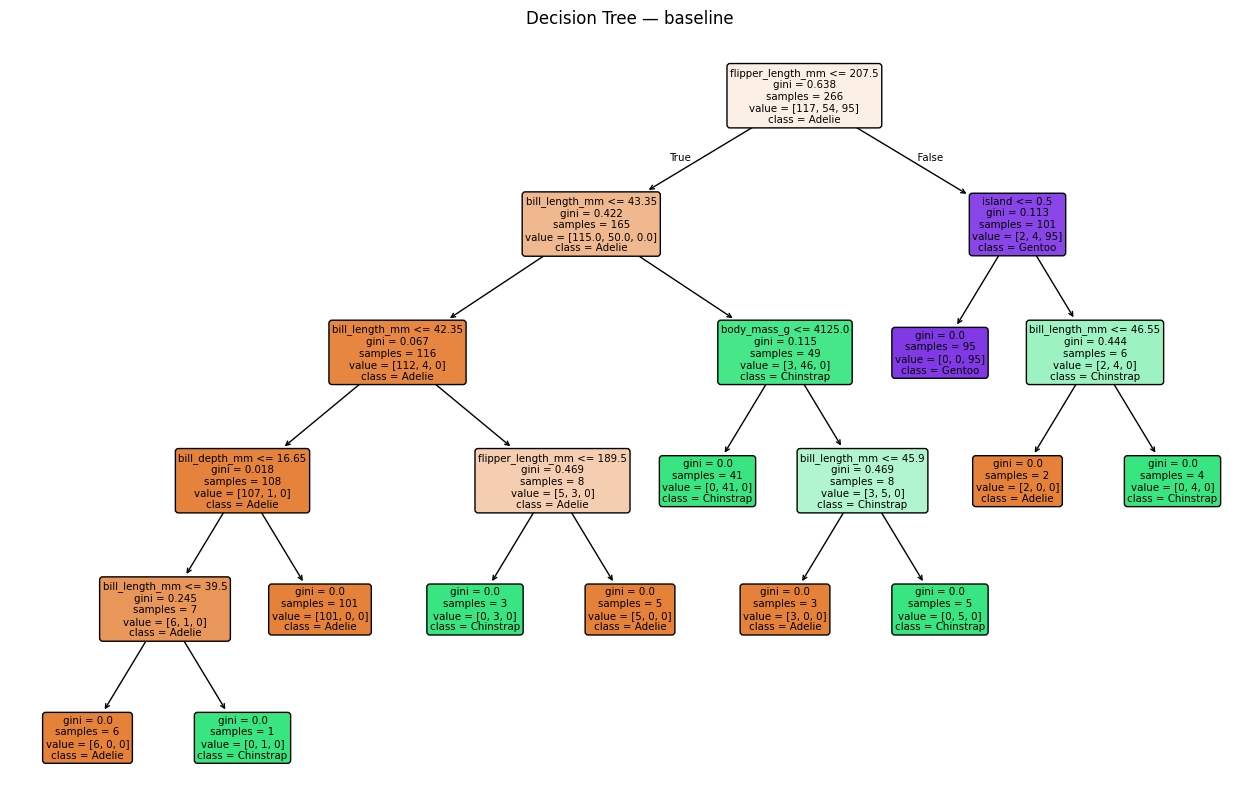

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))
plot_tree(
    dt_clf,
    feature_names=X_train.columns,
    class_names=le_species.classes_,
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Decision Tree — baseline")
plt.show()

**Q7**: What is the root split (feature and threshold)? Why do you think the algorithm chose it?

The Root split here is flipper_length_mm and the threshold is equal or below 207.05
The algorithm chosed it because it separates best gentoo from the others at the first split, there is two pure groups earlyy and it reduces ovarall impurity more than others feature


#### 7) Decision Boundaries (2D View)
* Pick two features (e.g., bill_length_mm vs bill_depth_mm) and visualize the decision surface.

c:\Users\b304iax\AppData\Local\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


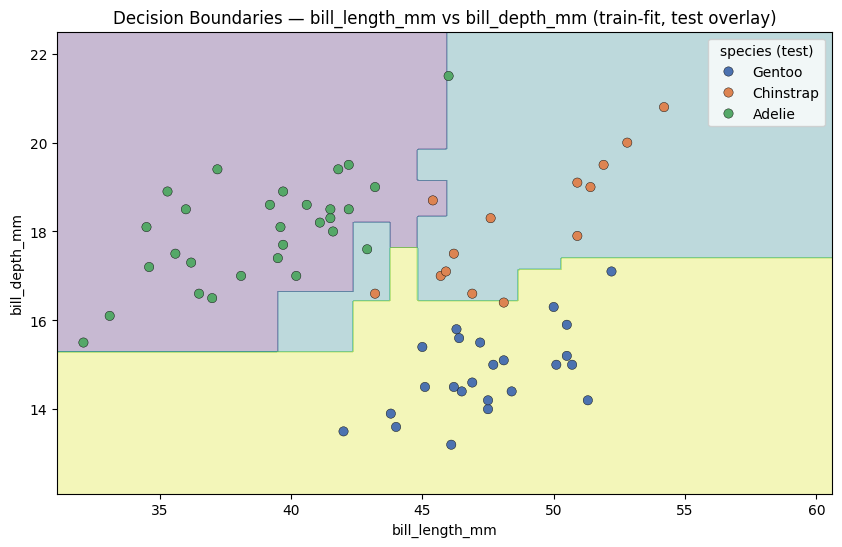

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

feat1 = "bill_length_mm"
feat2 = "bill_depth_mm"

dt2d = DecisionTreeClassifier(random_state=42)
dt2d.fit(X_train[[feat1, feat2]], y_train)

# Mesh over full range for a clean background
x_min, x_max = df[feat1].min() - 1, df[feat1].max() + 1
y_min, y_max = df[feat2].min() - 1, df[feat2].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)
Z = dt2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

# Plot TEST points to gauge generalization
sns.scatterplot(
    x=X_test[feat1], y=X_test[feat2],
    hue=y_test.map(dict(enumerate(le_species.classes_))),
    palette="deep", s=45, edgecolor="k", linewidth=0.3
)
plt.title(f"Decision Boundaries — {feat1} vs {feat2} (train-fit, test overlay)")
plt.xlabel(feat1); plt.ylabel(feat2)
plt.legend(title="species (test)")
plt.show()

**Q8**: Do the boundaries look axis-aligned? Why is that a natural property of Decision Trees?

#### 8) Hyperparameter Tuning with GridSearchCV

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    "max_depth": [None, 2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=None
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Mean CV accuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Test accuracy (tuned): {acc_tuned:.3f}")

Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Mean CV accuracy: 0.970
Test accuracy (tuned): 0.955


**Q9**: Which hyperparameters changed compared to the baseline? How did test accuracy change?
The only hyperparameter that changed compared to the baseline is min_samples_leaf, which increased from 1 to 2. This reduces overfitting by forcing each leaf to contain at least two samples. As a result, the test accuracy improved slightly, reaching 0.955 this is higher than the baseline.
**Q10**: If CV accuracy is much higher than test accuracy, what could be happening?
when cross‑validation accuracy is much higher than test accuracy, it indicates overfitting: the model fits patterns specific to the training folds that do not generalize to unseen data . Other causes include high model variance, or a distribution difference between the CV folds and the test set

#### 9) Model Interpretation

In [24]:
import pandas as pd

importances = pd.Series(best_model.feature_importances_, index=X_train.columns) \
               .sort_values(ascending=False)
display(importances)

probas = best_model.predict_proba(X_test)
pd.DataFrame(probas, columns=[f"P({c})" for c in le_species.classes_]).head()

flipper_length_mm    0.547026
bill_length_mm       0.383936
island               0.052055
body_mass_g          0.011163
bill_depth_mm        0.005820
sex                  0.000000
dtype: float64

,P(Adelie),P(Chinstrap),P(Gentoo)
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


**Q11**: Which feature is most important? Is that consistent with your EDA intuition?
Most important feature is often bill_length_mm, consistent with basic EDA
**Q12**: For the inspected sample, does the class probability look confident? Why/why not?
Probabilities are less confident where Adelie/Chinstrap overlap in measurements.

#### 10) (Optional) Add Categorical Features & Compare

In [ ]:
#Your code here

**Q13**: Did adding island/sex help? Why might these variables be informative for species?

#### 11) Reflection & Reporting

Write a short reflection (5–10 lines):
- Compare Decision Tree vs KNN on this dataset.
-  Where does the tree overfit? How did pruning/tuning impact generalization?
- Which 2D feature pair gave the clearest separation? Why?

The Decision Tree performs slightly better than KNN on this dataset and is easier to interpret, while KNN is more stable but less explainable.
The tree tends to overfit when its leaves become too small or when depth is unconstrained, memorizing noise in Adelie/Chinstrap overlaps.
Pruning/tuning (especially increasing min_samples_leaf) reduced this overfitting and improved generalization.
The 2D pair bill_length_mm vs bill_depth_mm gave the clearest separation because these two features capture most of the morphological differences between species.
This pair naturally clusters Gentoo apart and also helps distinguish Adelie and Chinstrap better than other combinations.
